In [1]:
#STEP 1- Import Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [2]:
print('Using local dataset files from the datasets folder.')

Using local dataset files from the datasets folder.


In [3]:
#Load Dataset
df = pd.read_csv(r'c:\Mini project\BrainDiseaseAI\datasets\Parkinsson disease.csv')
df.head()

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [4]:
#Data Preprocessing
X = df.drop(['status', 'name'], axis=1)  # features
y = df['status']  # label

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [6]:
#Train Model
model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [7]:
#Prediction
y_pred = model.predict(X_test)

In [ ]:
#Evaluation with performance metric graph and confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='binary', zero_division=0)
recall = recall_score(y_test, y_pred, average='binary', zero_division=0)
f1 = f1_score(y_test, y_pred, average='binary', zero_division=0)

print('Parkinson Speech Model Metrics')
print(f'Accuracy : {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall   : {recall:.4f}')
print(f'F1-score : {f1:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, zero_division=0))

metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-score']
metric_values = [accuracy, precision, recall, f1]

plt.figure(figsize=(8, 5))
bars = plt.bar(metric_names, metric_values, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
plt.ylim(0, 1)
plt.title('Parkinson Speech Model Performance Metrics')
plt.ylabel('Score')
plt.grid(axis='y', alpha=0.3)

for bar, value in zip(bars, metric_values):
    plt.text(bar.get_x() + bar.get_width() / 2, value + 0.01, f'{value:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:')
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Parkinson Speech Model Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

Accuracy: 0.9487179487179487
              precision    recall  f1-score   support

           0       1.00      0.71      0.83         7
           1       0.94      1.00      0.97        32

    accuracy                           0.95        39
   macro avg       0.97      0.86      0.90        39
weighted avg       0.95      0.95      0.95        39



In [ ]:
# Fast reusable evaluation helper for speech and clinical models
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

def evaluate_binary_model(y_true, y_pred, title):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='binary', zero_division=0)
    recall = recall_score(y_true, y_pred, average='binary', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='binary', zero_division=0)

    print(f'{title} Metrics')
    print(f'Accuracy : {accuracy:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall   : {recall:.4f}')
    print(f'F1-score : {f1:.4f}')
    print('\nClassification Report:')
    print(classification_report(y_true, y_pred, zero_division=0))

    metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-score']
    metric_values = [accuracy, precision, recall, f1]

    plt.figure(figsize=(8, 5))
    bars = plt.bar(metric_names, metric_values, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
    plt.ylim(0, 1)
    plt.title(f'{title} Performance Metrics')
    plt.ylabel('Score')
    plt.grid(axis='y', alpha=0.3)

    for bar, value in zip(bars, metric_values):
        plt.text(bar.get_x() + bar.get_width() / 2, value + 0.01, f'{value:.3f}', ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'{title} Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
    }

y_pred = model.predict(X_test)
speech_metrics = evaluate_binary_model(y_test, y_pred, 'Parkinson Speech Model')

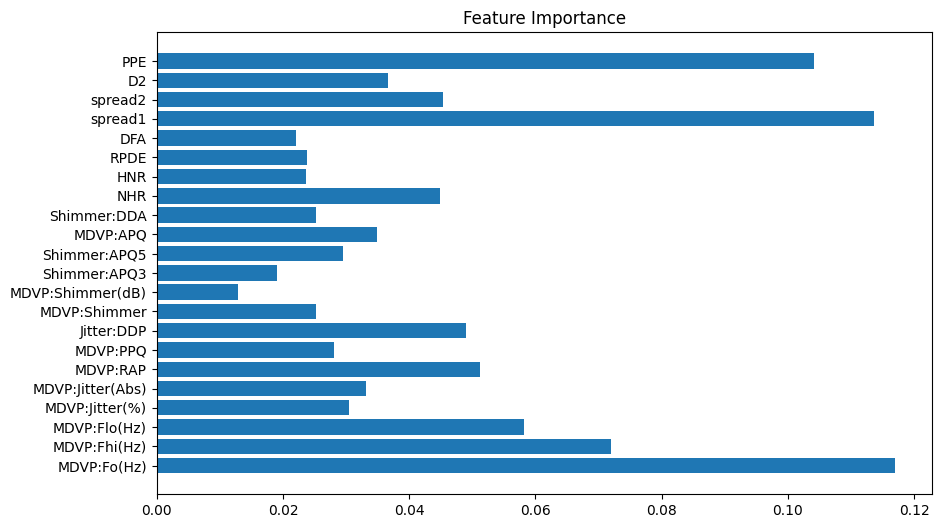

In [9]:
#Feature Importance (Explainability)
import matplotlib.pyplot as plt

importances = model.feature_importances_
features = X.columns
plt.figure(figsize=(10,6))
plt.barh(features, importances)
plt.title("Feature Importance")
plt.show()

In [2]:
print('Using local clinical dataset from the datasets folder.')

Using local clinical dataset from the datasets folder.


In [3]:
#load clicnal dataset
import pandas as pd

df_clinical = pd.read_csv(r'c:\Mini project\BrainDiseaseAI\datasets\parkinsons_disease_data.csv')
df_clinical.head()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,FunctionalAssessment,Tremor,Rigidity,Bradykinesia,PosturalInstability,SpeechProblems,SleepDisorders,Constipation,Diagnosis,DoctorInCharge
0,3058,85,0,3,1,19.619878,0,5.108241,1.380660,3.893969,...,1.572427,1,0,0,0,0,0,0,0,DrXXXConfid
1,3059,75,0,0,2,16.247339,1,6.027648,8.409804,8.513428,...,4.787551,0,1,0,1,0,1,0,1,DrXXXConfid
2,3060,70,1,0,0,15.368239,0,2.242135,0.213275,6.498805,...,2.130686,1,0,0,0,1,0,1,1,DrXXXConfid
3,3061,52,0,0,0,15.454557,0,5.997788,1.375045,6.715033,...,3.391288,1,1,1,0,0,0,1,1,DrXXXConfid
4,3062,87,0,0,1,18.616042,0,9.775243,1.188607,4.657572,...,3.200969,0,0,0,1,0,1,0,0,DrXXXConfid


In [14]:
#understand columns
df_clinical.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2105 entries, 0 to 2104
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   PatientID                 2105 non-null   int64  
 1   Age                       2105 non-null   int64  
 2   Gender                    2105 non-null   int64  
 3   Ethnicity                 2105 non-null   int64  
 4   EducationLevel            2105 non-null   int64  
 5   BMI                       2105 non-null   float64
 6   Smoking                   2105 non-null   int64  
 7   AlcoholConsumption        2105 non-null   float64
 8   PhysicalActivity          2105 non-null   float64
 9   DietQuality               2105 non-null   float64
 10  SleepQuality              2105 non-null   float64
 11  FamilyHistoryParkinsons   2105 non-null   int64  
 12  TraumaticBrainInjury      2105 non-null   int64  
 13  Hypertension              2105 non-null   int64  
 14  Diabetes

In [4]:
#Clean Columns
df_clinical.columns = df_clinical.columns.str.strip()

In [5]:
#data preprocessing
X_c = df_clinical.drop(['Diagnosis', 'PatientID', 'DoctorInCharge'], axis=1)
y_c = df_clinical['Diagnosis']

In [6]:
#Scaling
from sklearn.preprocessing import StandardScaler

scaler_c = StandardScaler()
X_c_scaled = scaler_c.fit_transform(X_c)

In [7]:
#Train-Test SPlit
from sklearn.model_selection import train_test_split

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_c_scaled, y_c, test_size=0.2, random_state=42
)

In [8]:
#Train model
from sklearn.ensemble import RandomForestClassifier

model_c = RandomForestClassifier()
model_c.fit(X_train_c, y_train_c)

RandomForestClassifier()

In [ ]:
#evaluate
from sklearn.metrics import accuracy_score, classification_report

y_pred_c = model_c.predict(X_test_c)

print("Clinical Accuracy:", accuracy_score(y_test_c, y_pred_c))
print(classification_report(y_test_c, y_pred_c))

Clinical Accuracy: 0.9049881235154394
              precision    recall  f1-score   support

           0       0.84      0.91      0.87       150
           1       0.95      0.90      0.92       271

    accuracy                           0.90       421
   macro avg       0.89      0.91      0.90       421
weighted avg       0.91      0.90      0.91       421



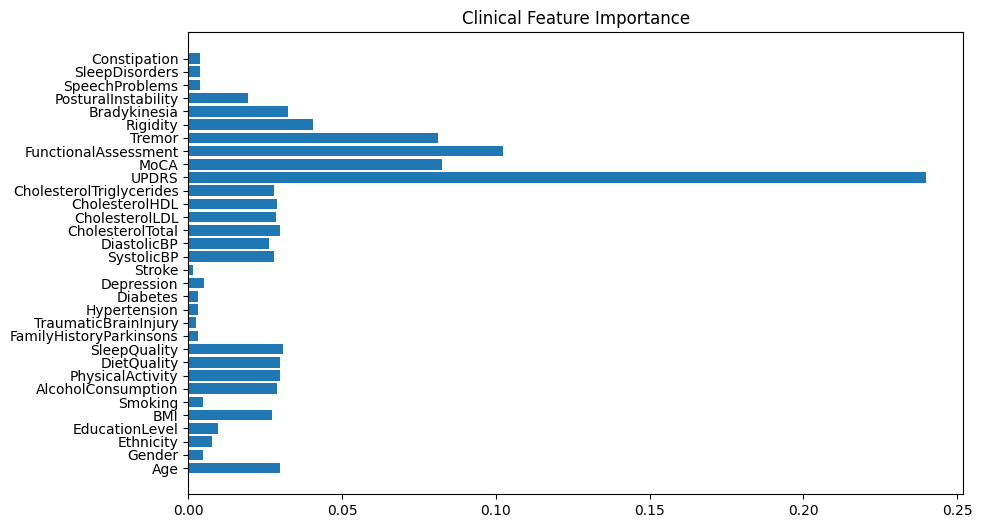

In [ ]:
#Explaianability
import matplotlib.pyplot as plt

importances = model_c.feature_importances_
features = X_c.columns

plt.figure(figsize=(10,6))
plt.barh(features, importances)
plt.title("Clinical Feature Importance")
plt.show()

In [ ]:
# STEP-3 -->>Fusion Logic
def final_prediction(speech_score=None, clinical_score=None):

    if speech_score is not None and clinical_score is not None:
        final_score = (speech_score + clinical_score) / 2

    elif speech_score is not None:
        final_score = speech_score

    elif clinical_score is not None:
        final_score = clinical_score

    else:
        return "No data provided"

    if final_score > 0.5:
        return "Parkinson’s Detected"
    else:
        return "Healthy"

In [ ]:
# FINAL FUNCTION (CONNECT EVRYTHING)
def predict_parkinsons_system(speech_input=None, clinical_input=None):

    speech_score = None
    clinical_score = None

    # Speech prediction
    if speech_input is not None:
        speech_input_scaled = scaler.transform(speech_input)
        speech_score = model.predict_proba(speech_input_scaled)[0][1]

    # Clinical prediction
    if clinical_input is not None:
        clinical_input_scaled = scaler_c.transform(clinical_input)
        clinical_score = model_c.predict_proba(clinical_input_scaled)[0][1]

    # Fusion
    if speech_score is not None and clinical_score is not None:
        final_score = (speech_score + clinical_score) / 2
    elif speech_score is not None:
        final_score = speech_score
    elif clinical_score is not None:
        final_score = clinical_score
    else:
        return "No data provided"

    # Final decision
    if final_score > 0.5:
        result = "Parkinson’s Detected"
    else:
        result = "Healthy"

    return {
        "result": result,
        "confidence": float(final_score),
        "speech_score": float(speech_score) if speech_score is not None else None,
        "clinical_score": float(clinical_score) if clinical_score is not None else None
    }

In [ ]:
#Create sample input
speech_input = X.iloc[0].values

In [ ]:
#Test your system
#Case 1: Only Speech
predict_parkinsons_system(speech_input=speech_input)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


{'result': 'Parkinson’s Detected',
 'confidence': np.float64(0.99),
 'speech_score': np.float64(0.99),
 'clinical_score': None}

In [ ]:
##Case 2: Only CLincial
clinical_input = X_c.iloc[0].values
predict_parkinsons_system(clinical_input=clinical_input)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


{'result': 'Healthy',
 'confidence': np.float64(0.08),
 'speech_score': None,
 'clinical_score': np.float64(0.08)}

In [ ]:
##Case 3: BOTH
predict_parkinsons_system(
    speech_input=X.iloc[0].values,
    clinical_input=X_c.iloc[0].values
)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


{'result': 'Parkinson’s Detected',
 'confidence': np.float64(0.535),
 'speech_score': np.float64(0.99),
 'clinical_score': np.float64(0.08)}

In [ ]:
#Test Multiple Samples (Speech)
for i in range(5):
    result = predict_parkinsons_system(
        speech_input=X_test.iloc[[i]]
    )
    print(f"Sample {i+1}:", result)

Sample 1: {'result': 'Parkinson’s Detected', 'confidence': 0.58, 'speech_score': 0.58, 'clinical_score': None}
Sample 2: {'result': 'Parkinson’s Detected', 'confidence': 0.65, 'speech_score': 0.65, 'clinical_score': None}
Sample 3: {'result': 'Parkinson’s Detected', 'confidence': 0.57, 'speech_score': 0.57, 'clinical_score': None}
Sample 4: {'result': 'Parkinson’s Detected', 'confidence': 0.55, 'speech_score': 0.55, 'clinical_score': None}
Sample 5: {'result': 'Parkinson’s Detected', 'confidence': 0.67, 'speech_score': 0.67, 'clinical_score': None}


In [ ]:
#Test Multiple Samples (Clinical)
for i in range(5):
    result = predict_parkinsons_system(
        clinical_input=X_test_c[i].reshape(1, -1)
    )
    print(f"Sample {i+1}:", result)

Sample 1: {'result': 'Healthy', 'confidence': 0.37, 'speech_score': None, 'clinical_score': 0.37}
Sample 2: {'result': 'Healthy', 'confidence': 0.49, 'speech_score': None, 'clinical_score': 0.49}
Sample 3: {'result': 'Healthy', 'confidence': 0.46, 'speech_score': None, 'clinical_score': 0.46}
Sample 4: {'result': 'Parkinson’s Detected', 'confidence': 0.52, 'speech_score': None, 'clinical_score': 0.52}
Sample 5: {'result': 'Healthy', 'confidence': 0.46, 'speech_score': None, 'clinical_score': 0.46}


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
#Test BOTH (Multimodal)
for i in range(5):
    result = predict_parkinsons_system(
        speech_input=X_test.iloc[[i]],              # DataFrame
        clinical_input=X_test_c[i].reshape(1, -1)   # Array
    )
    print(f"Sample {i+1}:", result)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Sample 1: {'result': 'Healthy', 'confidence': 0.475, 'speech_score': 0.58, 'clinical_score': 0.37}
Sample 2: {'result': 'Parkinson’s Detected', 'confidence': 0.5700000000000001, 'speech_score': 0.65, 'clinical_score': 0.49}
Sample 3: {'result': 'Parkinson’s Detected', 'confidence': 0.515, 'speech_score': 0.57, 'clinical_score': 0.46}
Sample 4: {'result': 'Parkinson’s Detected', 'confidence': 0.535, 'speech_score': 0.55, 'clinical_score': 0.52}
Sample 5: {'result': 'Parkinson’s Detected', 'confidence': 0.5650000000000001, 'speech_score': 0.67, 'clinical_score': 0.46}


In [ ]:
#saving model-SPEECH
import pickle

pickle.dump(model, open('speech_model.pkl', 'wb'))
pickle.dump(scaler, open('speech_scaler.pkl', 'wb'))

In [ ]:
#save mode-CLicnial
pickle.dump(model_c, open('clinical_model.pkl', 'wb'))
pickle.dump(scaler_c, open('clinical_scaler.pkl', 'wb'))

In [ ]:
#both(optional)
pickle.dump(X.columns.tolist(), open('speech_features.pkl', 'wb'))
pickle.dump(X_c.columns.tolist(), open('clinical_features.pkl', 'wb'))

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score


def plot_accuracy_graphs():
    plotted = False

    # 1) Keras training history plot (accuracy vs validation accuracy)
    history_candidates = []
    for name, value in globals().items():
        hist = getattr(value, "history", None)
        if isinstance(hist, dict):
            acc_key = "accuracy" if "accuracy" in hist else ("acc" if "acc" in hist else None)
            val_acc_key = "val_accuracy" if "val_accuracy" in hist else ("val_acc" if "val_acc" in hist else None)
            if acc_key:
                history_candidates.append((name, hist, acc_key, val_acc_key))

    if history_candidates:
        name, hist, acc_key, val_acc_key = history_candidates[0]
        epochs = range(1, len(hist[acc_key]) + 1)

        plt.figure(figsize=(8, 5))
        plt.plot(epochs, hist[acc_key], marker="o", label="Train Accuracy")
        if val_acc_key:
            plt.plot(epochs, hist[val_acc_key], marker="o", label="Validation Accuracy")
        plt.title(f"Accuracy Curve ({name})")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()
        plotted = True

    # 2) Sklearn-style final accuracy bar chart from y_test*/y_pred* pairs
    accuracy_items = []
    for test_name, y_true in globals().items():
        if not test_name.startswith("y_test"):
            continue
        suffix = test_name[len("y_test"):]
        pred_name = f"y_pred{suffix}"
        if pred_name in globals():
            y_hat = globals()[pred_name]
            try:
                score = accuracy_score(y_true, y_hat)
                label = suffix.replace("_", " ").strip().title() or "Model"
                accuracy_items.append((label, score))
            except Exception:
                pass

    if accuracy_items:
        labels = [item[0] for item in accuracy_items]
        scores = [item[1] for item in accuracy_items]

        plt.figure(figsize=(8, 5))
        bars = plt.bar(labels, scores)
        plt.ylim(0, 1)
        plt.ylabel("Accuracy")
        plt.title("Model Accuracy Comparison")
        plt.grid(axis="y", alpha=0.3)

        for bar, score in zip(bars, scores):
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                score + 0.01,
                f"{score:.3f}",
                ha="center",
                va="bottom",
            )

        plt.tight_layout()
        plt.show()
        plotted = True

    if not plotted:
        print("No accuracy data found yet. Run training/evaluation cells first, then run this cell.")


plot_accuracy_graphs()

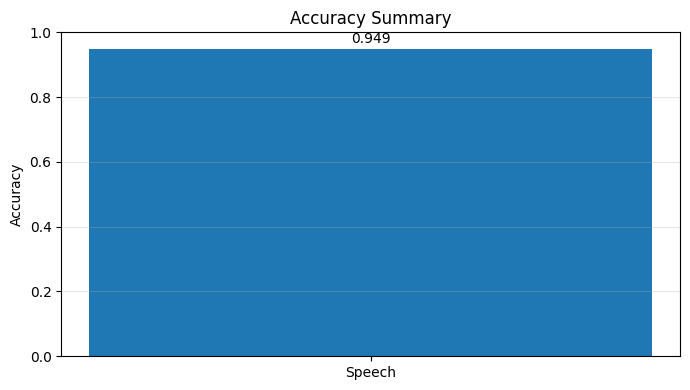

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score


def plot_accuracy_graphs():
    plotted = False

    # 1) Keras history support (if present)
    history_candidates = [
        globals().get('history'),
        globals().get('training_history'),
        globals().get('model_history'),
        globals().get('hist'),
    ]
    history_obj = next((h for h in history_candidates if h is not None), None)

    if history_obj is not None and hasattr(history_obj, 'history'):
        hist = history_obj.history
    elif isinstance(history_obj, dict):
        hist = history_obj
    else:
        hist = None

    if hist and ('accuracy' in hist or 'acc' in hist):
        acc_key = 'accuracy' if 'accuracy' in hist else 'acc'
        val_key = 'val_accuracy' if 'val_accuracy' in hist else ('val_acc' if 'val_acc' in hist else None)

        plt.figure(figsize=(8, 5))
        plt.plot(hist[acc_key], marker='o', label='Training Accuracy')
        if val_key:
            plt.plot(hist[val_key], marker='o', label='Validation Accuracy')
        plt.title('Model Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()
        plotted = True

    # 2) Sklearn-style pairs used in this notebook
    pairs = [
        ('Speech', 'y_test', 'y_pred'),
        ('Clinical', 'y_test_c', 'y_pred_c'),
    ]

    labels, scores = [], []
    for label, y_true_name, y_pred_name in pairs:
        if y_true_name in globals() and y_pred_name in globals():
            try:
                score = accuracy_score(globals()[y_true_name], globals()[y_pred_name])
                labels.append(label)
                scores.append(score)
            except Exception:
                pass

    if scores:
        plt.figure(figsize=(7, 4))
        bars = plt.bar(labels, scores, color=['#1f77b4', '#ff7f0e'][:len(scores)])
        plt.ylim(0, 1)
        plt.ylabel('Accuracy')
        plt.title('Accuracy Summary')
        plt.grid(axis='y', alpha=0.3)

        for bar, score in zip(bars, scores):
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                score + 0.01,
                f'{score:.3f}',
                ha='center',
                va='bottom',
            )

        plt.tight_layout()
        plt.show()
        plotted = True

    if not plotted:
        print('No accuracy data found yet. Run training/evaluation cells first, then run this cell.')


plot_accuracy_graphs()

Clinical Model Metrics
Accuracy : 0.9026
Precision: 0.9457
Recall   : 0.9004
F1-score : 0.9225

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87       150
           1       0.95      0.90      0.92       271

    accuracy                           0.90       421
   macro avg       0.89      0.90      0.90       421
weighted avg       0.91      0.90      0.90       421



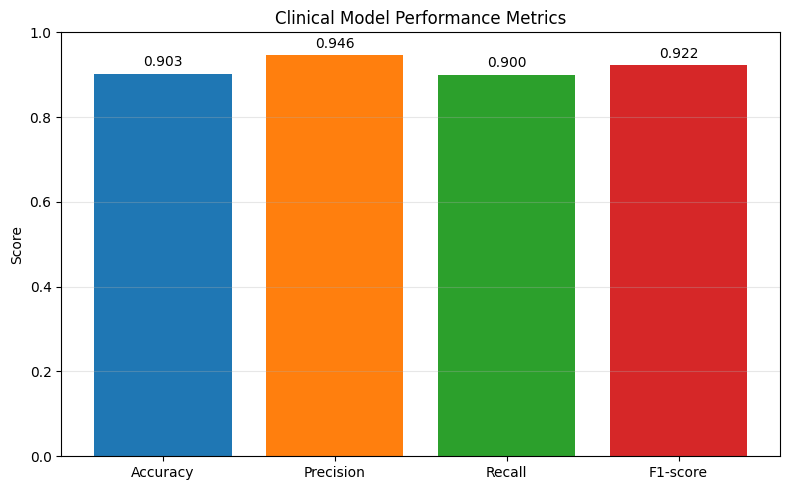

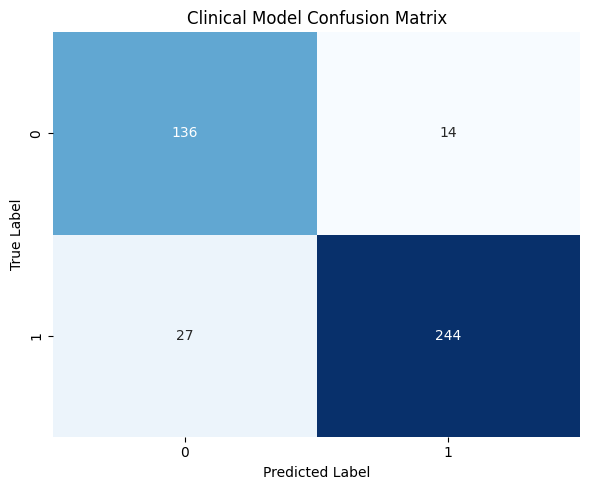

In [ ]:
# Clinical model evaluation using the same fast reusable helper
y_pred_c = model_c.predict(X_test_c)
clinical_metrics = evaluate_binary_model(y_test_c, y_pred_c, 'Parkinson Clinical Model')